# QualityPhys — Camera Remote Vital Signs Estimator (CRVSE)

## Notebook P2-09: ECG-Fitness Ensemble rPPG Extraction

Extracts rPPG signals from **ECG-Fitness** using a **three-algorithm ensemble** (POS, CHROM, GREEN), producing `ecg_fitness_ensemble.h5`.

### Pipeline

```
{subject}/{activity}/c920-1.avi  (30 fps, 1920×1080, frontal)
    │
    ├─ MediaPipe Face Mesh -> ROI masks (forehead, left cheek, right cheek)
    └─ Spatial mean RGB per ROI -> roi_rgb [T, 3, 3]
               │
               ├─ POS / CHROM / GREEN -> bandpass 0.7-3.5 Hz + z-score
               ├─ Spectral SQI per algorithm
               └─ Quality-weighted ensemble -> rppg_ensemble [T]

{subject}/{activity}/viatom-raw.csv  (125 Hz, col ' ECG' leading space)
    aligned via {subject}/{activity}/c920.csv unix timestamps
    -> z-score -> bandpass 0.5-40 Hz -> nk.ecg_clean -> nk.ecg_peaks
    -> RR intervals -> HRV + ECG SQI
    -> build_hr_continuous at 30fps
    -> reference_signal (z-scored ECG aligned to video window)

Gate: ECG SQI >= 0.5 AND ensemble SQI >= 0.07
Write to ecg_fitness_ensemble.h5
```

### Hard excludes

```
('11', '02') — ECG duration 1427s vs 60s video — unaligneable
'bbox', 'ForPublication' — not subjects
Activities 03, 04 — halogen lighting artefact

## 1. Environment Setup

In [1]:
import subprocess, sys

packages = [
    "neurokit2",
    "mediapipe",
    "h5py",
    "opencv-python",
    "scipy",
    "numpy",
    "pandas",
    "matplotlib"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages confirmed.")

All packages confirmed.


## 2. Imports 

In [2]:
import os, warnings, cv2, h5py, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from pathlib import Path
from scipy.signal import butter, filtfilt
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor" : "#1a1a2e",
    "axes.edgecolor" : "#444444",
    "axes.labelcolor" : "#e0e0e0",
    "xtick.color" : "#e0e0e0",
    "ytick.color" : "#e0e0e0",
    "text.color" : "#e0e0e0",
    "grid.color" : "#2a2a3e",
    "grid.linestyle" : "--",
    "grid.alpha" : 0.5,
    "figure.dpi" : 110,
})

DATASET_ROOT = "F:/ECG_Fitness_dataset" # adjust if needed
OUTPUT_DIR = "E:/QualityPhys"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset root : {DATASET_ROOT}")
print(f"Output dir : {OUTPUT_DIR}")

Dataset root : F:/ECG_Fitness_dataset
Output dir : E:/QualityPhys


## 3. Data Exploration

Computes `ECG_FS_ACTUAL` and `FPS_ACTUAL` from real data.

In [3]:
root = Path(DATASET_ROOT)
NON_SUBJECTS = {"bbox", "ForPublication"}

subject_dirs = sorted([d for d in root.iterdir() if d.is_dir() and d.name not in NON_SUBJECTS], key=lambda d: d.name)

print("=" * 60)
print("Dataset overview")
print("=" * 60)
print(f"Subject folders found : {len(subject_dirs)}")
print(f"Subjects : {[d.name for d in subject_dirs]}")

# ECG_FS from first viatom file
print()
print("=" * 60)
print("ECG sampling rate (computed from data)")
print("=" * 60)

s0 = subject_dirs[0]
act0 = next(d for d in sorted(s0.iterdir()) if d.is_dir())
viatom0 = act0 / "viatom-raw.csv"
df_v0 = pd.read_csv(viatom0)
ms0 = df_v0["milliseconds"].values.astype(np.float64)
span0 = float(ms0[-1] - ms0[0]) / 1000.0
ECG_FS_ACTUAL = len(ms0) / span0

print(f"First subject/activity : {s0.name}/{act0.name}")
print(f"Viatom samples : {len(ms0)}")
print(f"Timespan : {span0:.2f}s")
print(f"ECG_FS computed : {ECG_FS_ACTUAL:.4f} Hz")
print(f"Columns : {df_v0.columns.tolist()}")
print(f"Note: ' ECG' has leading space — use df[' ECG'] not df['ECG']")

# FPS from first video header
print()
print("=" * 60)
print("Video FPS from actual header")
print("=" * 60)

vid0 = act0 / "c920-1.avi"
cap0 = cv2.VideoCapture(str(vid0))
FPS_ACTUAL  = cap0.get(cv2.CAP_PROP_FPS)
nf0 = int(cap0.get(cv2.CAP_PROP_FRAME_COUNT))
w0 = int(cap0.get(cv2.CAP_PROP_FRAME_WIDTH))
h0 = int(cap0.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap0.release()

print(f"FPS from header : {FPS_ACTUAL:.4f} Hz")
print(f"Resolution : {w0}x{h0}")
print(f"n_frames (c920-1.avi) : {nf0}")

# c920.csv alignment file
print()
print("=" * 60)
print("c920.csv alignment file")
print("=" * 60)

# Summary
print()
print("=" * 60)
print("Summary — values that feed into Configuration cell")
print("=" * 60)
print(f"ECG_FS_ACTUAL : {ECG_FS_ACTUAL:.4f} Hz")
print(f"FPS_ACTUAL : {FPS_ACTUAL:.4f} Hz")
print(f"ECG/video ratio : {ECG_FS_ACTUAL:.1f} / {FPS_ACTUAL:.1f} = {ECG_FS_ACTUAL/FPS_ACTUAL:.3f} ECG samples per frame")


Dataset overview
Subject folders found : 17
Subjects : ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16']

ECG sampling rate (computed from data)
First subject/activity : 00/01
Viatom samples : 8720
Timespan : 69.72s
ECG_FS computed : 125.0735 Hz
Columns : ['milliseconds', ' ECG', ' ECG HR', ' PPG', ' PPG HR', ' SpO2', ' PI']
Note: ' ECG' has leading space — use df[' ECG'] not df['ECG']

Video FPS from actual header
FPS from header : 30.0000 Hz
Resolution : 1920x1080
n_frames (c920-1.avi) : 1800

c920.csv alignment file

Summary — values that feed into Configuration cell
ECG_FS_ACTUAL : 125.0735 Hz
FPS_ACTUAL : 30.0000 Hz
ECG/video ratio : 125.1 / 30.0 = 4.169 ECG samples per frame


## 4. Configuration

In [4]:
DATASET_NAME = "ecg_fitness_ensemble"
HDF5_PATH = os.path.join(OUTPUT_DIR, "ecg_fitness_ensemble.h5")
MP_MODEL_PATH = os.path.join(OUTPUT_DIR, "face_landmarker.task")

# Activities
# 01=cycling, 02=cycling recovery, 05=running, 06=running recovery
# EXCLUDED: 03, 04 (halogen lighting artefact)
ACTIVITIES_INCLUDE = ["01", "02", "05", "06"]
ACTIVITIES_EXCLUDE = ["03", "04"]
ACTIVITY_NAMES = {
    "01" : "cycling",
    "02" : "cycling_recovery",
    "05" : "running",
    "06" : "running_recovery",
}

# Hard excludes 
# ('11', '02') : ECG duration 1427s vs 60s video — unaligneable
HARD_EXCLUDE  = {("11", "02")}
NON_SUBJECTS  = {"bbox", "ForPublication"}

# Sampling rates — from exploration, NOT hardcoded
ECG_FS = ECG_FS_ACTUAL # 125.07 Hz (computed)
FPS_FALLBACK = FPS_ACTUAL # 30.0 Hz (from video header)

# Signal processing
RPPG_BP_LOW, RPPG_BP_HIGH  = 0.7, 3.5
ECG_BP_LOW, ECG_BP_HIGH = 0.5, 40.0  
BUTTER_ORDER = 4

# SQI gates
RPPG_SQI_THRESHOLD = 0.07   # ensemble spectral SQI  
RPPG_SQI_MIN_FLOOR = 0.01
ECG_SQI_THRESHOLD  = 0.5    # 1 - CV(RR)  

# Face detection
NO_FACE_THRESHOLD = 20.0

# HR physiological limits
HR_MIN = 40
HR_MAX = 200

# Algorithms — identical to NB06/NB07/NB08
ALGORITHMS = ["pos", "chrom", "green"]
HDF5_SKIP_KEY = "rppg_ensemble"

# ROI landmark indices — identical to NB06/NB07/NB08
FOREHEAD_LM    = [10,338,297,332,284,251,389,356,454,
                  323,361,288,397,365,379,378,400,377,
                  152,148,176,149,150,136,172,58, 132,
                  93, 234,127,162,21, 54, 103,67, 109]
LEFT_CHEEK_LM  = [234,227,116,123,147,213,192,214,210,
                  211,206,203,36, 101,119,229,228]
RIGHT_CHEEK_LM = [454,447,345,352,376,433,416,434,430,
                  431,426,423,266,330,348,449,448]
ROI_CONFIGS = {
    "forehead" : FOREHEAD_LM,
    "left_cheek" : LEFT_CHEEK_LM,
    "right_cheek" : RIGHT_CHEEK_LM,
}

print("NB_P2_09 configuration loaded.")
print(f"Output HDF5 : {HDF5_PATH}")
print(f"Activities included : {ACTIVITIES_INCLUDE}")
print(f"Activities excluded : {ACTIVITIES_EXCLUDE} (halogen)")
print(f"Hard excludes : {HARD_EXCLUDE}")
print(f"ECG_FS : {ECG_FS:.4f} Hz  (computed from data)")
print(f"FPS_FALLBACK : {FPS_FALLBACK:.4f} Hz  (from video header)")
print(f"rPPG band : {RPPG_BP_LOW}–3.5 Hz")
print(f"ECG band : {ECG_BP_LOW}–40.0 Hz")
print(f"Algorithms : {ALGORITHMS}")
print(f"Ensemble SQI >= : {RPPG_SQI_THRESHOLD}")
print(f"ECG SQI >= : {ECG_SQI_THRESHOLD}")

NB_P2_09 configuration loaded.
Output HDF5 : E:/QualityPhys\ecg_fitness_ensemble.h5
Activities included : ['01', '02', '05', '06']
Activities excluded : ['03', '04'] (halogen)
Hard excludes : {('11', '02')}
ECG_FS : 125.0735 Hz  (computed from data)
FPS_FALLBACK : 30.0000 Hz  (from video header)
rPPG band : 0.7–3.5 Hz
ECG band : 0.5–40.0 Hz
Algorithms : ['pos', 'chrom', 'green']
Ensemble SQI >= : 0.07
ECG SQI >= : 0.5


## 5. Build Recording Inventory


In [9]:
def build_inventory(dataset_root: str) -> pd.DataFrame:
    """
    Build per-recording inventory for ECG-Fitness.

    Structure: {subject}/{activity}/c920-1.avi + c920.csv + viatom-raw.csv
    Included activities: 01, 02, 05, 06.
    Excluded: 03/04 (halogen), bbox, ForPublication.
    Hard exclude: ('11', '02') — 1427s ECG vs 60s video, unaligneable.

    Subject key = bare folder name ('00'–'16'), matching HDF5 path.
    """
    root    = Path(dataset_root)
    records = []

    for subject_dir in sorted([d for d in root.iterdir() if d.is_dir() and d.name not in NON_SUBJECTS], key=lambda d: d.name):
        sid = subject_dir.name

        for act_dir in sorted([d for d in subject_dir.iterdir() if d.is_dir()], key=lambda d: d.name):
            act = act_dir.name

            # Activity filter
            if act not in ACTIVITIES_INCLUDE:
                continue

            # Hard exclude
            if (sid, act) in HARD_EXCLUDE:
                print(f"[HARD EXCLUDE] {sid}/{act}")
                continue

            vid_path = act_dir / "c920-1.avi" # frontal camera only
            c920_path = act_dir / "c920.csv"
            viatom_path = act_dir / "viatom-raw.csv"

            has_video = vid_path.exists() and vid_path.stat().st_size > 0
            has_ecg = viatom_path.exists()
            has_sync = c920_path.exists()

            # FPS from actual video header
            fps = FPS_FALLBACK
            if has_video:
                cap = cv2.VideoCapture(str(vid_path))
                fps_header = cap.get(cv2.CAP_PROP_FPS)
                cap.release()
                if fps_header > 0:
                    fps = fps_header

            records.append({
                "subject_id" : sid,
                "activity_id" : act,
                "activity_name" : ACTIVITY_NAMES[act],
                "video_path" : str(vid_path)    if has_video  else None,
                "c920_path" : str(c920_path)   if has_sync   else None,
                "viatom_path" : str(viatom_path) if has_ecg    else None,
                "fps" : fps,
                "has_video" : has_video,
                "has_ecg" : has_ecg,
                "has_sync" : has_sync,
            })

    df = pd.DataFrame(records)

    # HDF5 completion flag
    df["done"] = False
    if os.path.exists(HDF5_PATH):
        with h5py.File(HDF5_PATH, "r") as hf:
            for i, row in df.iterrows():
                hdf5_key = f"subjects/{row['subject_id']}/recordings/{row['activity_id']}/{HDF5_SKIP_KEY}"
                if hdf5_key in hf:
                    df.at[i, "done"] = True

    return df.sort_values(["subject_id","activity_id"]).reset_index(drop=True)


df_inventory = build_inventory(DATASET_ROOT)

print(f"Total recordings : {len(df_inventory)} ({df_inventory['subject_id'].nunique()} subjects x {len(ACTIVITIES_INCLUDE)} activities)")
print(f"Videos found : {df_inventory['has_video'].sum()}")
print(f"ECG files found : {df_inventory['has_ecg'].sum()}")
print(f"Sync files found : {df_inventory['has_sync'].sum()}")
print(f"Already done : {df_inventory['done'].sum()}")
print(f"Remaining : {(df_inventory['has_video'] & df_inventory['has_ecg'] & df_inventory['has_sync'] & ~df_inventory['done']).sum()}")
print()
print("Per-activity breakdown:")
print(df_inventory.groupby("activity_id")[["has_video","has_ecg","has_sync","done"]].sum())
print()
fps_arr = df_inventory["fps"].dropna()
print(f"FPS distribution: mean={fps_arr.mean():.4f}  std={fps_arr.std():.5f}  min={fps_arr.min():.4f}  max={fps_arr.max():.4f}")
print()
print(df_inventory[["subject_id","activity_id","activity_name","fps","has_video","has_ecg","done"]].to_string())


[HARD EXCLUDE] 11/02
Total recordings : 67 (17 subjects x 4 activities)
Videos found : 67
ECG files found : 67
Sync files found : 67
Already done : 0
Remaining : 67

Per-activity breakdown:
             has_video  has_ecg  has_sync  done
activity_id                                    
01                  17       17        17     0
02                  16       16        16     0
05                  17       17        17     0
06                  17       17        17     0

FPS distribution: mean=30.0000  std=0.00000  min=30.0000  max=30.0000

   subject_id activity_id     activity_name   fps  has_video  has_ecg   done
0          00          01           cycling  30.0       True     True  False
1          00          02  cycling_recovery  30.0       True     True  False
2          00          05           running  30.0       True     True  False
3          00          06  running_recovery  30.0       True     True  False
4          01          01           cycling  30.0       True     

## 6. Reference Signal Loaders 

ECG-Fitness uses Viatom wristband ECG at 125 Hz. Alignment to video via c920.csv unix timestamp join. PPG is completely skipped (flat 056 across all 100 recordings)


In [17]:
def bandpass_filter(signal: np.ndarray, fs: float, low: float, high: float, order: int = 4) ->np.ndarray:
    """Zero-phase Butterworth bandpass."""
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b,a, signal).astype(np.float32)


def zscore(signal: np.ndarray) -> np.ndarray:
    """Zero-mean unit variance normalisation."""
    mu, sigma = signal.mean(), signal.std() + 1e-8
    return ((signal - mu) / sigma).astype(np.float32)


def load_viatom_signal(viatom_path: str, c920_path: str) -> dict | None:
    """
    Load and align Viatom ECG to the video window usng c920.csv timestamps.
    
    viatom-raw.csv format (7 cols with header, leading spaces in col names):
        milliseconds | ' ECG' | ' ECG HR' | ' PPG' | ' PPG HR' | ' SpO2' | ' PI' 
        
    c920.csv format (2 cols no header):
        unix_ms_per_frame | value (1800 rows = 1800 video frames)
        
    Alignment: timestamp join
        mask = (viatom_ms >= 920[0]) & (viatom_ms <= c920[-1])
        ecg_aligned = ecg[mask]
        
    NaN handling: single NaN row in 07/02 - dropna before alignment.
    
    PPG is flat -56 in all recordings
    
    Returns dict with:
        ecg_raw : np.ndarray [N] - raw ADC values within video window
        ms_aligned : np.ndarray [N] - unix ms for each ECG sample
        ecg_fs : float - computed from timestamp span/n_samples
        vid_start_ms : float - video start unix ms
        vid_end_ms : float - video end unix ms
        n_ecg_aligned : int
    """
    if not viatom_path or not os.path.exists(viatom_path):
        return None
    if not c920_path or not os.path.exists(c920_path):
        return None

    try:
        df_v = pd.read_csv(viatom_path).dropna() # dropna handles 07/02 NaN row
        df_c = pd.read_csv(c920_path, header=None, names = ["unix_ms", "value"])

        ms_raw = df_v["milliseconds"].values.astype(np.float64)
        ecg_raw = df_v[" ECG"].values.astype(np.float64)

        # ECG_FS from total span
        span_s = float(ms_raw[-1] - ms_raw[0]) / 1000.0
        ecg_fs = len(ms_raw) / span_s if span_s > 0 else ECG_FS

        # Video window from c920.csv
        vid_start_ms = float(df_c["unix_ms"].iloc[0])
        vid_end_ms = float(df_c["unix_ms"].iloc[-1])

        # Timestamp join - extract ECG within video window
        mask = (ms_raw >= vid_start_ms) & (ms_raw <= vid_end_ms)
        ecg_aligned = ecg_raw[mask]
        ms_aligned = ms_raw[mask]

        if len(ecg_aligned) < int(ecg_fs * 5): # need at least 5s of ECG
            print(f"[WARN] ECG window too short after alignment: {len(ecg_aligned)} samples")
            return None

        return {
            "ecg_raw" : ecg_aligned,
            "ms_aligned" : ms_aligned,
            "ecg_fs" : ecg_fs,
            "vid_start_ms" : vid_start_ms,
            "vid_end_ms" : vid_end_ms,
            "n_ecg_aligned" : len(ecg_aligned),
        }

    except Exception as e:
        print(f"[WARN] Viatom load error {viatom_path}: {e}")
        return None


def detect_ecg_peaks(ecg_raw: np.ndarray, ecg_fs: float) -> tuple:
    """
    ECG peak detection pipeline.
    
    1. Z-score - raw ADC values span ±10M. NeuroKit2 thresholds scale with 
        amplitude, so norm,alise first.
    2. Banpass 0.5 - 40 Hz - captures QRS complex (narrow ~0.1s spike) and 
        low-frequency baseline drift.
    3. nk,ecg_clean + nk.ecg_peaks.
    
    Returns (peak_idx, rr_ms, hr_mean, ecg_filt).
    """
    try:
        fs = int(round(ecg_fs))
        ecg_z = zscore(ecg_raw.astype(np.float64))
        ecg_filt = bandpass_filter(ecg_z, ecg_fs, ECG_BP_LOW, ECG_BP_HIGH)
        ecg_clean = nk.ecg_clean(ecg_filt, sampling_rate=fs)
        peak_dict, _ = nk.ecg_peaks(ecg_clean, sampling_rate=fs)
        peak_idx = np.where(peak_dict["ECG_R_Peaks"] == 1)[0]

        if len(peak_idx) < 3:
            return peak_idx, np.array([]), float("nan"), ecg_filt

        rr_ms = np.diff(peak_idx) / ecg_fs * 1000.0
        hr_mean = float(60000.0 / rr_ms.mean())
        return peak_idx, rr_ms, hr_mean, ecg_filt

    except Exception as e:
        print(f"[WARN] ECG peak detection failed: {e}")
        return np.array([]), np.array([]), float("nan"), np.zeros_like(ecg_raw, dtype=np.float32)


def compute_hrv_features(rr_ms: np.ndarray) -> dict:
    """Time-domain HRV from RR intervals."""
    nan = {
        "mean_rr_ms" : float("nan"), 
        "sdnn_ms" : float("nan"),
        "rmssd_ms" : float("nan"), 
        "pnn50_pct" : float("nan"), 
        "hr_mean_bpm" : float("nan")
    }

    if len(rr_ms) < 3:
        return nan

    rr = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr) < 3:
        return nan

    diff = np.diff(rr)
    
    return {
        "mean_rr_ms" : float(rr.mean()),
        "sdnn_ms" : float(rr.std()),
        "rmssd_ms" : float(np.sqrt(np.mean(diff ** 2))),
        "pnn50_pct" : float((np.abs(diff) > 50).mean() * 100),
        "hr_mean_bpm" : float(60000.0 / rr.mean()),
    }
    

def compute_ecg_sqi(rr_ms: np.ndarray) -> float:
    """
    ECG SQI = 1 - CV(RR)
    Higher = more regular RR intervals = cleaner ECG reference.
    """
    if len(rr_ms) < 3:
        return float("nan")
    rr = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr) < 3:
        return float("nan")
    cv = rr.std() / (rr.mean() + 1e-8)
    return float(1.0 - min(cv, 1.0))


def build_hr_continuous(peak_idx: np.ndarray, rr_ms: np. ndarray, source_fs: float, 
                        n_frames: int, target_fps: float) -> np.ndarray:
    """
    Continuous HR at video frame rate from ECG R-peaks.
    Maps each R-peak (ECG samples at source_fs=125 Hz) to the corresponding 
    video frame (target_fps=30Hz), then forward-fills.
    """
    hr_cont = np.full(n_frames, np.nan, dtype=np.float32)
    if len(peak_idx) < 2 or len(rr_ms) == 0:
        return hr_cont
    for i, idx in enumerate(peak_idx[:-1]):
        fi = int(idx / source_fs * target_fps)
        if 0 <= fi < n_frames:
            hr_cont[fi] = 60000.0 / rr_ms[i]
    last = np.nan
    for i in range(n_frames):
        if not np.isnan(hr_cont[i]):
            last = hr_cont[i]
        elif not np.isnan(last):
            hr_cont[i] = last
    return hr_cont


# Sanity check
print("Reference signal functions defined.")
print()
test_row = df_inventory[(df_inventory["has_video"]) & (df_inventory["has_ecg"]) & (df_inventory["has_sync"])].iloc[0]
print(f"Sanity check: {test_row['subject_id']}/{test_row['activity_id']}")
ecg_data = load_viatom_signal(test_row["viatom_path"], test_row["c920_path"])
if ecg_data:
    peak_idx, rr_ms, hr_mean, ecg_filt = detect_ecg_peaks(ecg_data["ecg_raw"], ecg_data["ecg_fs"])
    hrv = compute_hrv_features(rr_ms)
    ecg_sqi = compute_ecg_sqi(rr_ms)
    hr_cont = build_hr_continuous(peak_idx, rr_ms, ecg_data["ecg_fs"], 300, FPS_FALLBACK)
    print(f"ECG aligned : {ecg_data['n_ecg_aligned']} samples  ecg_fs={ecg_data['ecg_fs']:.2f} Hz")
    print(f"ECG range (raw) : min={ecg_data['ecg_raw'].min():.0f}  max={ecg_data['ecg_raw'].max():.0f}")
    print(f"R-peaks found : {len(peak_idx)}  RR mean={rr_ms.mean():.1f} ms  HR={hr_mean:.1f} BPM")
    print(f"ECG SQI : {ecg_sqi:.3f}")
    print(f"RMSSD : {hrv['rmssd_ms']:.1f} ms  SDNN={hrv['sdnn_ms']:.1f} ms")
    print(f"hr_cont[300] : min={np.nanmin(hr_cont):.1f}  max={np.nanmax(hr_cont):.1f} Nan={np.sum(np.isnan(hr_cont))}")

Reference signal functions defined.

Sanity check: 00/01
ECG aligned : 7495 samples  ecg_fs=125.07 Hz
ECG range (raw) : min=-8847360  max=3211264
R-peaks found : 82  RR mean=723.7 ms  HR=82.9 BPM
ECG SQI : 0.944
RMSSD : 28.1 ms  SDNN=40.2 ms
hr_cont[300] : min=79.0  max=88.3 Nan=26


## 7. MediaPipe ROI Extraction

In [18]:
if not os.path.exists(MP_MODEL_PATH):
    print("Downloading MediaPipe face landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, MP_MODEL_PATH)
    print("Downloaded.")
else:
    print(f"Face landmarker model present: {MP_MODEL_PATH}")


def get_roi_mask(landmarks, frame_shape: tuple, lm_indices: list) -> np.ndarray:
    """Binary polygon mask for one ROI from MediaPipe landmarks."""
    h, w = frame_shape[:2]
    pts = np.array([[int(landmarks[i].x * w), int(landmarks[i].y * h)] for i in lm_indices], dtype=np.int32)
    mask = np.zeros((h,w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask


def extract_roi_signals(video_path: str, roi_configs: dict, max_frames: int = None) -> dict:
    """
    Single-pass video extraction. 
    Returns roi_rgb [T, n_rois, 3], actual_fps, n_frames, no_face_pct.
    """
    cap = cv2.VideoCapture(video_path)
    actual_fps = cap.get(cv2.CAP_PROP_FPS)
    if actual_fps <= 0:
        actual_fps = FPS_FALLBACK

    roi_names = list(roi_configs.keys())
    roi_sigs = {name: [] for name in roi_names}
    n_frames = 0
    no_face = 0

    base_opts = mp_python.BaseOptions(model_asset_path=MP_MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_opts,
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1,
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and n_frames >= max_frames:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            ts_ms = int((n_frames / actual_fps) * 1000)
            result = landmarker.detect_for_video(mp_img, ts_ms)

            if result.face_landmarks:
                lm = result.face_landmarks[0]
                for name, indices in roi_configs.items():
                    mask = get_roi_mask(lm, rgb.shape, indices)
                    if mask.sum() > 0:
                        r = rgb[:, :, 0][mask == 1].mean()
                        g = rgb[:, :, 1][mask == 1].mean()
                        b = rgb[:, :, 2][mask == 1].mean()
                        roi_sigs[name].append(np.array([r, g, b], dtype=np.float32))
                    else:
                        fb = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                        roi_sigs[name].append(fb)
            else:
                no_face += 1
                for name in roi_configs:
                    fb = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                    roi_sigs[name].append(fb)

            n_frames += 1

    cap.release()
    arrays = [np.array(roi_sigs[name]) for name in roi_names]
    roi_rgb = np.stack(arrays, axis=1).astype(np.float32)

    return {
        "roi_rgb" : roi_rgb,
        "actual_fps" : actual_fps,
        "n_frames" : n_frames,
        "no_face_pct": round(100 * no_face / max(n_frames, 1), 1),
    }


print("ROI extraction function defined.")

Face landmarker model present: E:/QualityPhys\face_landmarker.task
ROI extraction function defined.


## 8. rPPG Algorithms + Spectral SQI + Ensemble

In [19]:
def apply_pos(roi_rgb: np.ndarray, fps: float) -> np.ndarray:
    """
    POS algorithm. Per ROI independently, then average.
    Cn = C / mean(C), S = P @ Cn.T, h = S[0] + alpha*S[1].
    """
    P = np.array([[0, 1, -1], [-2, 1, 1]], dtype=np.float64)
    n_rois = roi_rgb.shape[1]
    signals = []
    for r in range(n_rois):
        C = roi_rgb[:, r, :].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        S = P @ Cn.T
        h = S[0] + (S[0].std() / (S[1].std() + 1e-8)) * S[1]
        signals.append(h)
    combined = np.mean(signals, axis=0)
    return zscore(bandpass_filter(combined, fps, RPPG_BP_LOW, RPPG_BP_HIGH))


def apply_chrom(roi_rgb: np.ndarray, fps: float) -> np.ndarray:
    """
    CHROM algorithm. Per ROI independently, then average.
    Xs = 3R-2G, Ys = 1.5R+G-1.5B, H = Xs - alpha*Ys.
    """
    n_rois = roi_rgb.shape[1]
    signals = []
    for r in range(n_rois):
        C = roi_rgb[:, r, :].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        Xs = 3.0 * Cn[:, 0] - 2.0 * Cn[:, 1]
        Ys = 1.5 * Cn[:, 0] + Cn[:, 1] - 1.5 * Cn[:, 2]
        alpha = Xs.std() / (Ys.std() + 1e-8)
        signals.append(Xs - alpha * Ys)
    combined = np.mean(signals, axis=0)
    return zscore(bandpass_filter(combined, fps, RPPG_BP_LOW, RPPG_BP_HIGH))



def apply_green(roi_rgb: np.ndarray, fps: float) -> np.ndarray:
    """
    GREEN channel mean across ROIs.
    Oxyhaemoglobin absorption peak ~550 nm. No artefact rejection.
    """
    green = roi_rgb[:, :, 1].mean(axis=1)
    return zscore(bandpass_filter(green, fps, RPPG_BP_LOW, RPPG_BP_HIGH))


ALGORITHM_FN = {"pos": apply_pos, "chrom": apply_chrom, "green": apply_green}


def compute_spectral_sqi(signal: np.ndarray, fps: float) -> float:
    """Peak-to-band power ratio in cardiac band."""
    N = len(signal)
    freqs = np.fft.rfftfreq(N, 1.0 / fps)
    power = np.abs(np.fft.rfft(signal - signal.mean())) ** 2
    mask = (freqs >= RPPG_BP_LOW) & (freqs <= RPPG_BP_HIGH)
    band = power[mask]
    if band.sum() < 1e-10:
        return 0.0
    pk = np.argmax(band)
    lo = max(0, pk - 3)
    hi = min(len(band), pk + 4)
    return float(band[lo:hi].sum() / band.sum())


def compute_ensemble(signals: dict, sqis: dict) -> tuple:
    """Quality-proportional weighted sum."""
    raw_w = np.array([max(sqis[a], RPPG_SQI_MIN_FLOOR) for a in ALGORITHMS], dtype=np.float64)
    weights = raw_w / raw_w.sum()
    stacked = np.stack([signals[a] for a in ALGORITHMS], axis=0)
    ensemble = (stacked * weights[:, None]).sum(axis=0).astype(np.float32)
    return ensemble, weights.astype(np.float32)


print("rPPG algorithm + SQI + ensemble functions defined.")
print(f"Algorithms : {ALGORITHMS}")
print("SQI type : spectral peak-to-band ratio")
print("Ensemble : quality-weighted soft fusion")

rPPG algorithm + SQI + ensemble functions defined.
Algorithms : ['pos', 'chrom', 'green']
SQI type : spectral peak-to-band ratio
Ensemble : quality-weighted soft fusion


## 9. Single-Recording Pipeline

Skip conditions: 
* `no_ecg` - viatom - raw.csv or c920.csv missing
* `ecg_alignment_failed` - too few ECG samples within video window
* `flat_ecg` - ECG amplitude range < 1000 ADC units
* `ecg_sqi_low` - RR irregularity SQI < 0.5
* `implausible_hr` - HR outside 40-200 BPM
* `no_face` -> 20% frames without face detection
* `ensemble_sqi_low` - ensemble spectral SQI < 0.07

In [22]:
def process_single_recording(row: pd.Series, max_frames: int = None) -> tuple:
    """
    Full ensemble rPPG preprocessing pipeline for one ECG-Fitness recording.
    
    Reference strategy:
        ECG (Viatom 125 Hz, aligned via c920.csv) -> z-score -> bandpass
        -> R-peaks -> HRV + ECG SQI + hr_continuous + reference signal.
    
    rPPG strategy:
        roi_rgb from c920-1.avi -> POS + CHROM + GREEN in parallel
        Per-algorithm spectral SQI -> quality-weighted ensemble 
        Gate on Ensemble SQI
        
    Returns (result_dict, reason_string), result_dict is None if skipped.
    """
    subject_id = row["subject_id"]
    activity_id = row["activity_id"]
    label = f"{subject_id}/{activity_id}"

    # Step 1: Load and align ECG to video window
    ecg_data = load_viatom_signal(row["viatom_path"], row["c920_path"])
    if ecg_data is None:
        return None, "no_ecg"

    ecg_raw = ecg_data["ecg_raw"]
    ecg_fs = ecg_data["ecg_fs"]

    if len(ecg_raw) < int(ecg_fs * 5):
        return Nonem, f"ecg_elignment_failed ({len(ecg_raw)} samples)"

    # Flat ECG check - raw ADC range should be >> 1000
    if float(ecg_raw.max()) - float(ecg_raw.min()) < 1000:
        return None, "flat_ecg"

    # Step 2: ECG peak detection -> HRV + ECG SQI
    peak_idx, rr_ms, hr_mean_ecg, ecg_filt = detect_ecg_peaks(ecg_raw, ecg_fs)

    if np.isnan(hr_mean_ecg) or hr_mean_ecg < HR_MIN or hr_mean_ecg > HR_MAX:
        return None, f"implausible_hr ({hr_mean_ecg:.1f} BPM)"

    ecg_sqi = compute_ecg_sqi(rr_ms)
    if not np.isnan(ecg_sqi) and ecg_sqi < ECG_SQI_THRESHOLD:
        return None, f"ecg_sqi_low ({ecg_sqi:.3f})"

    hrv = compute_hrv_features(rr_ms)

    # Step 3: ROI extraction from c920-1.avi
    roi_out = extract_roi_signals(row["video_path"], ROI_CONFIGS, max_frames=max_frames)
    roi_rgb = roi_out["roi_rgb"]
    n_frames = roi_out["n_frames"]
    actual_fps = roi_out["actual_fps"]
    no_face = roi_out["no_face_pct"]

    if no_face > NO_FACE_THRESHOLD:
        return None, f"no_face ({no_face:.1f}%)"

    # Step 4: Three rPPG algorithms
    rppg_signals = {}
    rppg_sqis = {}
    for alg in ALGORITHMS:
        sig = ALGORITHM_FN[alg](roi_rgb, actual_fps)
        rppg_signals[alg] = sig
        rppg_sqis[alg] = compute_spectral_sqi(sig, actual_fps)

    # Step 5: Quality-weighted ensemble
    rppg_ensemble, ens_weights = compute_ensemble(rppg_signals, rppg_sqis)
    sqi_ensemble = compute_spectral_sqi(rppg_ensemble, actual_fps)

    if sqi_ensemble < RPPG_SQI_THRESHOLD:
        return None, f"ensemble_sqi_low ({sqi_ensemble:.3f})"

    # Step 6: hr_continuous from ECG peaks + reference_signal
    # hr_continous: ECG R-peaks at 125 Hz -> video fps (30Hz)
    # reference signal: z-scored filtered ECG, trimmed to n_frames
    hr_continuous = build_hr_continuous(peak_idx, rr_ms, ecg_fs, n_frames, actual_fps)

    # Resample ECG to video frame rate for reference_signal storage
    ecg_z_filt = zscore(ecg_filt)
    n_ecg = len(ecg_z_filt)
    reference_signal = np.interp(np.linspace(0, 1, n_frames), np.linspace(0, 1, n_ecg), ecg_z_filt).astype(np.float32)

    # Step 7: Trim all signals to shortest common length 
    T = min(n_frames, len(rppg_ensemble), len(hr_continuous), len(reference_signal), roi_rgb.shape[0])
    hr_mean = float(np.nanmean(hr_continuous[:T])) if not np.all(np.isnan(hr_continuous[:T])) else hr_mean_ecg
    rr_storage = rr_ms.astype(np.float32) if len(rr_ms) > 0 else np.array([], dtype=np.float32)

    sqis_str = " ".join(f"{a}={rppg_sqis[a]:.3f}" for a in ALGORITHMS)
    print(f"{label} T={T} HR={hr_mean:.1f} ecg_sqi={ecg_sqi:.3f} "
          f"ens={sqi_ensemble:.3f} [{sqis_str}] no_face={no_face:.1f}% fps={actual_fps:.2f}")

    result = {
        # rPPG signals
        "rppg_pos" : rppg_signals["pos"][:T],
        "rppg_chrom" : rppg_signals["chrom"][:T],
        "rppg_green" : rppg_signals["green"][:T],
        "rppg_ensemble" : rppg_ensemble[:T],
        "ensemble_weights" : ens_weights,
        # Supporting signals
        "roi_rgb" : roi_rgb[:T],
        "reference_signal" : reference_signal[:T],
        "hr_continuous" : hr_continuous[:T],
        "rr_intervals" : rr_storage,
        # Scalar labels
        "hr_mean" : float(hr_mean),
        "rmssd_ms" : hrv["rmssd_ms"],
        "sdnn_ms" : hrv["sdnn_ms"],
        "pnn50_pct" : hrv["pnn50_pct"],
        # SQI
        "ecg_sqi" : float(ecg_sqi) if not np.isnan(ecg_sqi) else -1.0,
        "sqi_pos" : float(rppg_sqis["pos"]),
        "sqi_chrom" : float(rppg_sqis["chrom"]),
        "sqi_green" : float(rppg_sqis["green"]),
        "sqi_ensemble" : float(sqi_ensemble),
        # Metadata
        "subject_id" : subject_id,
        "activity_id" : activity_id,
        "activity_name" : ACTIVITY_NAMES[activity_id],
        "dataset" : DATASET_NAME,
        "reference_type" : "ECG_continuous",
        "n_frames" : T,
        "fps" : actual_fps,
        "no_face_pct" : float(no_face),
        "ecg_fs" : float(ecg_fs),
    }
    return result, "ok"


print("process_single_recording defined.")

process_single_recording defined.


## 10. Single-Recording Demo (300 frames)

Demo: 00/01 | fps=30.0000

00/01 T=300 HR=84.0 ecg_sqi=0.944 ens=0.448 [pos=0.591 chrom=0.440 green=0.282] no_face=0.0% fps=30.00

Signal shapes:
rppg_pos               : (300,)  dtype=float32  nan=0
rppg_chrom             : (300,)  dtype=float32  nan=0
rppg_green             : (300,)  dtype=float32  nan=0
rppg_ensemble          : (300,)  dtype=float32  nan=0
roi_rgb                : (300, 3, 3)  dtype=float32  nan=0
reference_signal       : (300,)  dtype=float32  nan=0
hr_continuous          : (300,)  dtype=float32  nan=26
rr_intervals           : (81,)  dtype=float32  nan=0
ensemble_weights       : (3,)  dtype=float32  nan=0

Scalar labels:
hr_mean                : 84.01811981201172
rmssd_ms               : 28.069076768518897
sdnn_ms                : 40.244297231367234
pnn50_pct              : 7.5
ecg_sqi                : 0.9443926439660892
sqi_ensemble           : 0.4481143057346344
no_face_pct            : 0.0
fps                    : 30.0
ecg_fs                 : 125.0735093733415

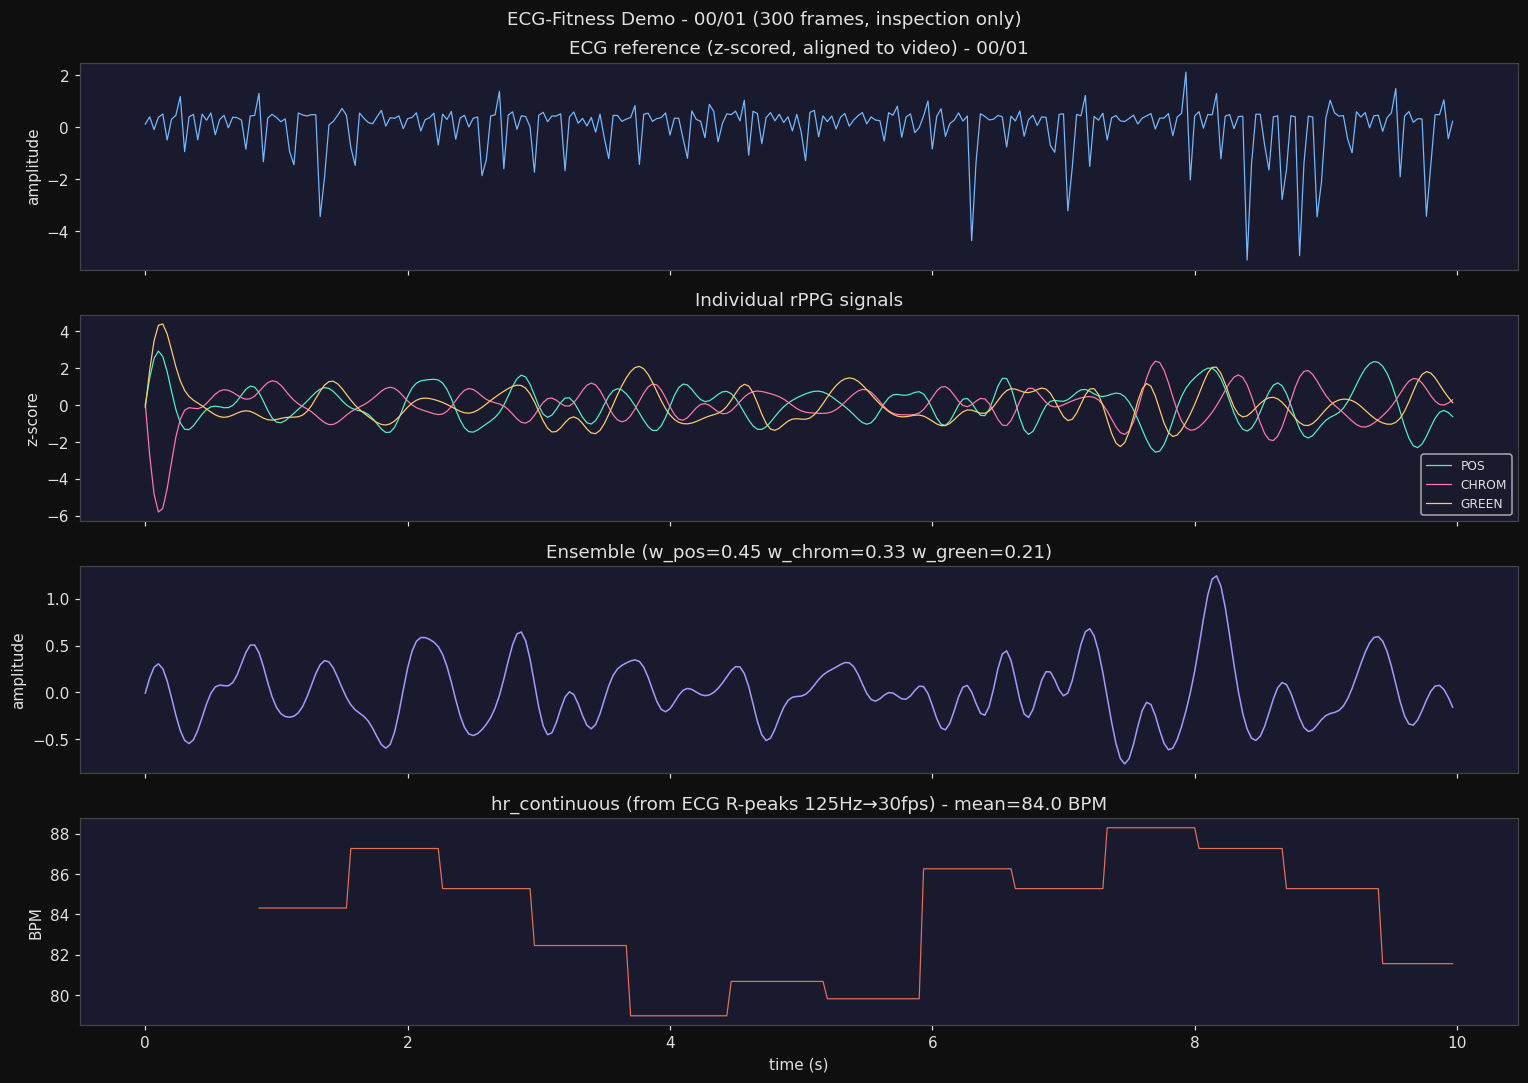


Demo complete — result NOT written to HDF5.
Full run (Cell 12) writes all recordings with complete frame counts.


In [23]:
demo_row = df_inventory[df_inventory["has_video"] & df_inventory["has_ecg"] & df_inventory["has_sync"]].iloc[0]
print(f"Demo: {demo_row['subject_id']}/{demo_row['activity_id']} | fps={demo_row['fps']:.4f}")
print()

demo_result, demo_reason = process_single_recording(demo_row, max_frames=300)

if demo_result is not None:
    print()
    print("Signal shapes:")
    for key in ["rppg_pos", "rppg_chrom", "rppg_green", "rppg_ensemble","roi_rgb", 
                "reference_signal", "hr_continuous", "rr_intervals", "ensemble_weights"]:
        arr = demo_result.get(key)
        if arr is not None and hasattr(arr, "shape"):
            nan_c = int(np.sum(np.isnan(arr.astype(float)))) if arr.dtype != object else 0
            print(f"{key:<22} : {arr.shape}  dtype={arr.dtype}  nan={nan_c}")
    print()
    print("Scalar labels:")
    for key in ["hr_mean", "rmssd_ms", "sdnn_ms", "pnn50_pct", "ecg_sqi", "sqi_ensemble", 
                "no_face_pct", "fps", "ecg_fs", "n_frames", "activity_id", "reference_type"]:
        print(f"{key:<22} : {demo_result.get(key, 'N/A')}")
    print()
    print("Ensemble weights:")
    for alg, w in zip(ALGORITHMS, demo_result["ensemble_weights"]):
        print(f"{alg:<6} : {w:.4f}")

    # 4-panel signal plot
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    T = len(demo_result["rppg_ensemble"])
    t = np.arange(T) / demo_result["fps"]

    axes[0].plot(t, demo_result["reference_signal"], color="#74b9ff", lw=0.8)
    axes[0].set_title(f"ECG reference (z-scored, aligned to video) - {demo_row['subject_id']}/{demo_row['activity_id']}")
    axes[0].set_ylabel("amplitude")

    axes[1].plot(t, demo_result["rppg_pos"], color="#55efc4", lw=0.8, label="POS")
    axes[1].plot(t, demo_result["rppg_chrom"], color="#fd79a8", lw=0.8, label="CHROM")
    axes[1].plot(t, demo_result["rppg_green"], color="#fdcb6e", lw=0.8, label="GREEN")
    axes[1].set_title("Individual rPPG signals")
    axes[1].set_ylabel("z-score")
    axes[1].legend(fontsize=8)

    w = demo_result["ensemble_weights"]
    axes[2].plot(t, demo_result["rppg_ensemble"], color="#a29bfe", lw=1.0)
    axes[2].set_title(f"Ensemble (w_pos={w[0]:.2f} w_chrom={w[1]:.2f} w_green={w[2]:.2f})")
    axes[2].set_ylabel("amplitude")

    axes[3].plot(t, demo_result["hr_continuous"], color="#e17055", lw=0.8)
    axes[3].set_title(f"hr_continuous (from ECG R-peaks 125Hz→30fps) - mean={demo_result['hr_mean']:.1f} BPM")
    axes[3].set_ylabel("BPM")
    axes[3].set_xlabel("time (s)")

    plt.suptitle(f"ECG-Fitness Demo - {demo_row['subject_id']}/{demo_row['activity_id']} (300 frames, inspection only)", fontsize=12)
    plt.tight_layout()

    plt.show()
    print()
    print("Demo complete — result NOT written to HDF5.")
else:
    print(f"Demo skipped: {demo_reason}")

## 11. HDF5 Write Functions

In [28]:
def write_recordings_to_hdf5(h5_file: h5py.File, result: dict) -> bool:
    """
    Write one ECG-Fitness recording to HDF5.
    Path: subjects/{subject_id}/recordings/{activity_id}/
    Resume-safe: returns False if group already exists.
    """
    subj = result["subject_id"]
    act = result["activity_id"]
    path = f"subjects/{subj}/recordings/{act}"

    if path in h5_file:
        return False

    grp = h5_file.require_group(path)

    for ds_name in [
        "rppg_pos", "rppg_chrom", "rppg_green", "rppg_ensemble", "ensemble_weights",
        "roi_rgb", "reference_signal", "hr_continuous", "rr_intervals",]:
        grp.create_dataset(ds_name, data=result[ds_name],compression="gzip", compression_opts=4)

    std_attrs = {
        "subject_id" : result["subject_id"],
        "activity_id" : result["activity_id"],
        "activity_name" : result["activity_name"],
        "dataset" : result["dataset"],
        "reference_type": result["reference_type"],
        "n_frames" : result["n_frames"],
        "fps" : result["fps"],
        "ecg_fs" : result["ecg_fs"],
        "hr_mean" : result["hr_mean"],
        "rmssd_ms" : result["rmssd_ms"]  if not np.isnan(result["rmssd_ms"]) else -1.0,
        "sdnn_ms" : result["sdnn_ms"] if not np.isnan(result["sdnn_ms"]) else -1.0,
        "pnn50_pct" : result["pnn50_pct"] if not np.isnan(result["pnn50_pct"]) else -1.0,
        "ecg_sqi" : result["ecg_sqi"],
        "sqi_pos" : result["sqi_pos"],
        "sqi_chrom" : result["sqi_chrom"],
        "sqi_green" : result["sqi_green"],
        "sqi_ensemble" : result["sqi_ensemble"],
        "no_face_pct" : result["no_face_pct"],
    }
    for key, value in std_attrs.items():
        grp.attrs[key] = value

    return True


def initialise_hdf5(output_path: str) -> h5py.File:
    """
    Open or create ecg_fitness_ensemble.h5 in append mode.
    Top-level metadata written once on first open.
    """
    h5 = h5py.File(output_path, "a")

    if "metadata" not in h5:
        meta = h5.require_group("metadata")
        meta.attrs["dataset_name"] = DATASET_NAME
        meta.attrs["source"] = "ECG-Fitness"
        meta.attrs["preprocessing_version"] = "1.0"
        meta.attrs["algorithms"] = str(ALGORITHMS)
        meta.attrs["rppg_bp_low"] = RPPG_BP_LOW
        meta.attrs["rppg_bp_high"] = RPPG_BP_HIGH
        meta.attrs["ecg_bp_low"] = ECG_BP_LOW
        meta.attrs["ecg_bp_high"] = ECG_BP_HIGH
        meta.attrs["ecg_fs"] = ECG_FS
        meta.attrs["rppg_sqi_threshold"] = RPPG_SQI_THRESHOLD
        meta.attrs["ecg_sqi_threshold"] = ECG_SQI_THRESHOLD
        meta.attrs["no_face_threshold"] = NO_FACE_THRESHOLD
        meta.attrs["reference_type"] = "ECG_continuous"
        meta.attrs["activities_included"] = str(ACTIVITIES_INCLUDE)
        meta.attrs["activities_excluded"] = str(ACTIVITIES_EXCLUDE)
        meta.attrs["hard_excludes"] = str(list(HARD_EXCLUDE))
        meta.attrs["ppg_note"] = "PPG flat -56 all recordings — skipped entirely"
        meta.attrs["n_subjects"] = 17
        meta.attrs["hdf5_schema"] = "subjects/{subject_id}/recordings/{activity_id}/"
        meta.attrs["mcd_schema_compat"] = "True"
        print("HDF5 metadata group initialised.")

    return h5


print("HDF5 write functions defined.")


HDF5 write functions defined.


## 12. Full Pipeline


In [ ]:
def process_all_recordings(df_inventory: pd.DataFrame, hdf5_path: str, flush_every: int = 10) -> pd.DataFrame:
    """
    Process all recordings with safe stop/resume.
    Safe stop : create STOP_PREPROCESSING.txt in OUTPUT_DIR.
    Resume: re-run cell, already-logged (subject, activity) pairs skipped in O(1).
    Crash recovery: HDF5 + log flushed every flush_every recordings.
    """
    STOP_FILE = os.path.join(OUTPUT_DIR, "STOP_PREPROCESSING.txt")
    LOG_PATH = os.path.join(OUTPUT_DIR, f"processing_log_{DATASET_NAME}.csv")

    log_rows = []
    stop_requested = False
    processed_count = 0

    if os.path.exists(LOG_PATH) and os.path.getsize(LOG_PATH) > 0:
        df_existing = pd.read_csv(LOG_PATH)
        log_rows = df_existing.to_dict("records")
        existing_keys = set(zip(df_existing["subject"].astype(str), df_existing["activity"].astype(str)))
        print(f"Resumin - {len(log_rows)} log entries from previous run.")
    else:
        existing_keys = set()
        print("Starting fresh run.")

    df_todo = df_inventory[df_inventory["has_video"] & df_inventory["has_ecg"] & df_inventory["has_sync"]]
    total = len(df_todo)

    already_done = sum(1 for _, row in df_todo.iterrows() if (row["subject_id"], row["activity_id"]) in existing_keys)
    if already_done > 0:
        print(f"Resume: {already_done}/{total} already logged - skipping.")
    print()
    print(f"To stop safely: create {STOP_FILE}")
    print(f"Pipeline stops after current recording completes.")
    print()

    try:
        with initialise_hdf5(hdf5_path) as h5:
            for i, (_, row) in enumerate(df_todo.iterrows()):
                subject = row["subject_id"]
                activity = row["activity_id"]
                key = (subject, activity)

                if os.path.exists(STOP_FILE):
                    print()
                    print(f"Stop file detected at [{i+1}/{total}] {subject}/{activity}")
                    print("Flushing HDF5 and saving log...")
                    stop_requested = True
                    break

                if key in existing_keys:
                    continue
    
                hdf5_grp = f"subject/{subject}/recordings/{activity}"
                if hdf5_grp in h5:
                    log_rows.append({
                        "subject": subject, 
                        "activity": activity,
                        "status": "resumed", 
                        "skip_reason": "already_in_hdf5",
                        "hr_mean": np.nan, 
                        "fps": row["fps"],
                        "ecg_sqi": np.nan, 
                        "sqi_pos": np.nan,
                        "sqi_chrom": np.nan, 
                        "sqi_green": np.nan,
                        "sqi_ensemble": np.nan, 
                        "n_frames": 0,
                        "no_face_pct": np.nan, 
                        "rmssd_ms": np.nan,
                    })
                    existing_keys.add(key)
                    continue
    
                if (i + 1) % 10 == 0 or i == 0:
                    n_proc = sum(1 for r in log_rows if r.get("status") == "processed")
                    pct = (i + 1) / total * 100
                    print(f"[{i + 1:03d}/{total}] {pct:.1f}% processed this session: {processed_count} total in log: {n_proc}")
    
                print(f"[{i+1:03d}/{total}] {subject}/{activity}", end="  ")
                result, reason = process_single_recording(row)
    
                if result is not None:
                    write_recordings_to_hdf5(h5, result)
                    processed_count += 1
                    log_rows.append({
                            "subject" : subject,
                            "activity" : activity,
                            "status" : "processed",
                            "skip_reason" : "ok",
                            "hr_mean" : result["hr_mean"],
                            "fps" : result["fps"],
                            "ecg_sqi" : result["ecg_sqi"],
                            "sqi_pos" : result["sqi_pos"],
                            "sqi_chrom" : result["sqi_chrom"],
                            "sqi_green" : result["sqi_green"],
                            "sqi_ensemble" : result["sqi_ensemble"],
                            "w_pos" : float(result["ensemble_weights"][0]),
                            "w_chrom" : float(result["ensemble_weights"][1]),
                            "w_green" : float(result["ensemble_weights"][2]),
                            "n_frames" : result["n_frames"],
                            "no_face_pct" : result["no_face_pct"],
                            "rmssd_ms" : result["rmssd_ms"],
                    })
                    existing_keys.add(key)
    
                    if processed_count % flush_every == 0:
                        h5.flush()
                        pd.DataFrame(log_rows).to_cvs(LOG_PATH, index=False)
                        print(f"[flush] HDF5 + log save({processed_count} new this session)")
    
                else:
                    print(f"SKIPPED - {reason}")
                    log_rows.append({
                        "subject": subject, 
                        "activity": activity,
                        "status": "skipped", 
                        "skip_reason": reason,
                        "hr_mean": np.nan, 
                        "fps": row["fps"],
                        "ecg_sqi": np.nan, 
                        "sqi_pos": np.nan,
                        "sqi_chrom": np.nan, 
                        "sqi_green": np.nan,
                        "sqi_ensemble": np.nan, 
                        "n_frames": 0,
                        "no_face_pct": np.nan, 
                        "rmssd_ms": np.nan,
                    })
                    existing_keys.add(key)

            h5.flush()
        
    except KeyboardInterrupt:
        print()
        print("KeyboardInterrupt - HDF5 closed safely.")
        print(f"Processed {processed_count} recordings this session.")

    df_log = pd.DataFrame(log_rows) if log_rows else pd.DataFrame(
        columns=["subject","activity","status","skip_reason","hr_mean","fps",
                 "ecg_sqi","sqi_pos","sqi_chrom","sqi_green","sqi_ensemble",
                 "n_frames","no_face_pct","rmssd_ms"]
    )
    df_log.to_csv(LOG_PATH, index=False)

    print()
    print("=" * 60)
    if stop_requested:
        print("Pipeline stopped safely - safe to shut down.")
        print(f"Delete {STOP_FILE} before resuming.")
    else:
        print("Processing complete.")
    print("=" * 60)

    processed = (df_log["status"] == "processed").sum() if len(df_log) else 0
    skipped = (df_log["status"] == "skipped").sum() if len(df_log) else 0
    resumed = (df_log["status"] == "resumed").sum() if len(df_log) else 0
    print(f"Total processed : {processed}")
    print(f"Total skipped : {skipped}")
    print(f"Total resumed : {resumed}")
    print(f"This session : {processed_count} new recordings written")
    print()

    if skipped > 0:
        print("Skip reasons:")
        reasons = (df_log[df_log["status"] == "skipped"]["skip_reason"].str.split(" ").str[0].value_counts())
        for r, c in reasons.items():
            print(f"{r:<35} : {c}")
    print()

    print("Per-activity pass rate:")
    for act in ACTIVITIES_INCLUDE:
        sub = df_log[df_log["activity"] == act]
        n_proc = (sub["status"] == "processed").sum()
        print(f"{act} {n_proc}/{len(sub)} ({n_proc/max(len(sub),1)*100:.1f}%) [{ACTIVITY_NAMES[act]}]")
    print()
    print(f"Log : {LOG_PATH}")
    print(f"HDF5 : {hdf5_path}")
    return df_log


print("Full pipeline ready.")
print(f"Total recordings to process : {(df_inventory['has_video'] & df_inventory['has_ecg'] & df_inventory['has_sync']).sum()}")
print()
df_log = process_all_recordings(df_inventory, HDF5_PATH) 

Full pipeline ready.
Total recordings to process : 67

Resumin - 0 log entries from previous run.

To stop safely: create E:/QualityPhys\STOP_PREPROCESSING.txt
Pipeline stops after current recording completes.

[001/67] 1.5% processed this session: 0 total in log: 0
[001/67] 00/01  

# 13. Post-Processing Validation

In [30]:
def validate_hdf5(hdf5_path: str) -> pd.DataFrame:
    """
    Post-processing validation for ecg_fitness_ensemble.h5.
    Checks: metadata, shape consistency, ensemble weights sum,
    HR by activity (expect running > cycling > recovery),
    SQI distributions, HRV sanity, no_face outliers.
    """
    records = []

    with h5py.File(hdf5_path, "r") as h5:
        print(f"Top-level groups : {list(h5.keys())}")
        print()
        print("Metadata:")
        for key, val in h5["metadata"].attrs.items():
            print(f"{key} : {val}")
        print()

        subjects_sorted = sorted(h5["subjects"].keys())
        for subj_key in subjects_sorted:
            for act_key in sorted(h5[f"subjects/{subj_key}/recordings"].keys()):
                grp = h5[f"subjects/{subj_key}/recordings/{act_key}"]
                attrs = dict(grp.attrs)

                T = grp["rppg_ensemble"].shape[0]
                for ds in ["rppg_pos", "rppg_chrom", "rppg_green", "reference_signal", "hr_continuous"]:
                    assert grp[ds].shape[0] == T,f"{ds} mismatch in {subj_key}/{act_key}: {grp[ds].shape[0]} vs {T}"

                weights = grp["ensemble_weights"][:]
                w_sum = float(weights.sum())
                assert abs(w_sum - 1.0) < 1e-4, \
                    f"{subj_key}/{act_key}: ensemble weights sum={w_sum:.4f}"

                records.append({
                    "subject" : subj_key,
                    "activity" : act_key,
                    "n_frames" : T,
                    "fps" : attrs.get("fps"),
                    "ecg_fs" : attrs.get("ecg_fs"),
                    "hr_mean" : attrs.get("hr_mean"),
                    "rmssd_ms" : attrs.get("rmssd_ms"),
                    "ecg_sqi" : attrs.get("ecg_sqi"),
                    "sqi_pos" : attrs.get("sqi_pos"),
                    "sqi_chrom" : attrs.get("sqi_chrom"),
                    "sqi_green" : attrs.get("sqi_green"),
                    "sqi_ensemble" : attrs.get("sqi_ensemble"),
                    "w_pos" : float(weights[0]),
                    "w_chrom" : float(weights[1]),
                    "w_green" : float(weights[2]),
                    "no_face_pct" : attrs.get("no_face_pct"),
                    "n_beats" : grp["rr_intervals"].shape[0],
                    "activity_name" : attrs.get("activity_name"),
                    "reference_type" : attrs.get("reference_type"),
                })

    df = pd.DataFrame(records)
    n_subj = df["subject"].nunique()

    print("=" * 60)
    print(f"Subject coverage : {n_subj} / 17 expected")
    print(f"Total recordings : {len(df)} / {n_subj * len(ACTIVITIES_INCLUDE)} for {n_subj} subjects")
    missing = n_subj * len(ACTIVITIES_INCLUDE) - len(df)
    if missing > 0:
        print(f"[WARN] {missing} recordings missing - check skip log")
    print()

    # HR by activity — expect running (05,06) > cycling (01,02)
    print("HR by activity (expect running > cycling):")
    print(df.groupby("activity")["hr_mean"].agg(["mean","std","min","max"]).round(1).to_string())
    print()

    print("n_frames distribution:")
    print(f"range : {df['n_frames'].min()} - {df['n_frames'].max()}")
    print(f"mean : {df['n_frames'].mean():.0f}")
    print()

    print("SQI distributions:")
    for col, label, gate in [
        ("sqi_pos", "POS", None),
        ("sqi_chrom", "CHROM", None),
        ("sqi_green", "GREEN", None),
        ("sqi_ensemble","ENSEMBLE", RPPG_SQI_THRESHOLD),
        ("ecg_sqi", "ECG SQI", ECG_SQI_THRESHOLD),
    ]:
        s = df[col].dropna()
        gate_str = f"gate={gate} below_gate={(s < gate).sum()}" if gate else ""
        print(f"{label:<12}: mean={s.mean():.3f}  min={s.min():.3f}  max={s.max():.3f}{gate_str}")
    print()

    print("Ensemble weights (mean across recordings):")
    for alg, col in zip(ALGORITHMS, ["w_pos", "w_chrom", "w_green"]):
        w = df[col].dropna()
        print(f"{alg:<8}: mean={w.mean():.3f}  std={w.std():.3f}  min={w.min():.3f}  max={w.max():.3f}")
    print()

    print("HRV label sanity:")
    rmssd_valid = df["rmssd_ms"].replace(-1.0, np.nan).dropna()
    print(f"RMSSD range  : {rmssd_valid.min():.1f} – {rmssd_valid.max():.1f} ms")
    print(f"Sentinel -1.0: {(df['rmssd_ms'] == -1.0).sum()} recordings")
    print()

    bad_face = df[df["no_face_pct"] > 1.0].sort_values("no_face_pct", ascending=False)
    if len(bad_face):
        print(f"no_face > 1% ({len(bad_face)} recordings):")
        print(bad_face[["subject","activity","no_face_pct","n_frames"]].to_string(index=False))
    else:
        print("no_face outliers: none")
    print()

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle("ECG-Fitness Ensemble — Post-Processing Validation",
                 fontsize=11, fontweight="bold")
    plot_data = [
        ("sqi_pos","POS", "#55efc4", None),
        ("sqi_chrom","CHROM", "#fd79a8", None),
        ("sqi_green", "GREEN", "#fdcb6e", None),
        ("sqi_ensemble", "ENSEMBLE", "#a29bfe", RPPG_SQI_THRESHOLD),
        ("ecg_sqi", "ECG SQI", "#74b9ff", ECG_SQI_THRESHOLD),
    ]
    for ax, (col, label, color, gate) in zip(axes, plot_data):
        s = df[col].dropna()
        ax.hist(s, bins=15, color=color, alpha=0.8, edgecolor="white")
        if gate is not None:
            ax.axvline(gate, color="#ff7675", ls="--", lw=1.5, label=f"gate={gate}")
            ax.legend(fontsize=7)
        ax.set_title(f"{label}\nmean={s.mean():.3f}  n={len(s)}", fontsize=9)
        ax.set_xlabel("SQI")
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df

df_validation = validate_hdf5(HDF5_PATH)


Top-level groups : ['metadata']

Metadata:
activities_excluded : ['03', '04']
activities_included : ['01', '02', '05', '06']
algorithms : ['pos', 'chrom', 'green']
dataset_name : ecg_fitness_ensemble
ecg_bp_high : 40.0
ecg_bp_low : 0.5
ecg_fs : 125.07350937334157
ecg_sqi_threshold : 0.5
hard_excludes : [('11', '02')]
hdf5_schema : subjects/{subject_id}/recordings/{activity_id}/
mcd_schema_compat : True
n_subjects : 17
no_face_threshold : 20.0
ppg_note : PPG flat -56 all recordings — skipped entirely
preprocessing_version : 1.0
reference_type : ECG_continuous
rppg_bp_high : 3.5
rppg_bp_low : 0.7
rppg_sqi_threshold : 0.07
source : ECG-Fitness



KeyError: "Unable to synchronously open object (object 'subjects' doesn't exist)"

In [31]:
import h5py

with h5py.File(HDF5_PATH, "r") as h5:
    print("Top-level keys:", list(h5.keys()))

Top-level keys: ['metadata']
